In [1]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Specificity_model_mlp.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Specificity_model_mlp.csv", index=False)


                               Feature     Q1     Q3  \
0                       bh_5' overhang  0.571  0.817   
1                         dsDNA target  0.612  0.961   
2  ah_maximal consecutive paired bases  0.066  0.985   
3                           ah_5' stem  0.984  0.989   

   Median Spearman Correlation  
0                        0.644  
1                        0.877  
2                        0.637  
3                        0.987  


/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_34193/1960053500.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


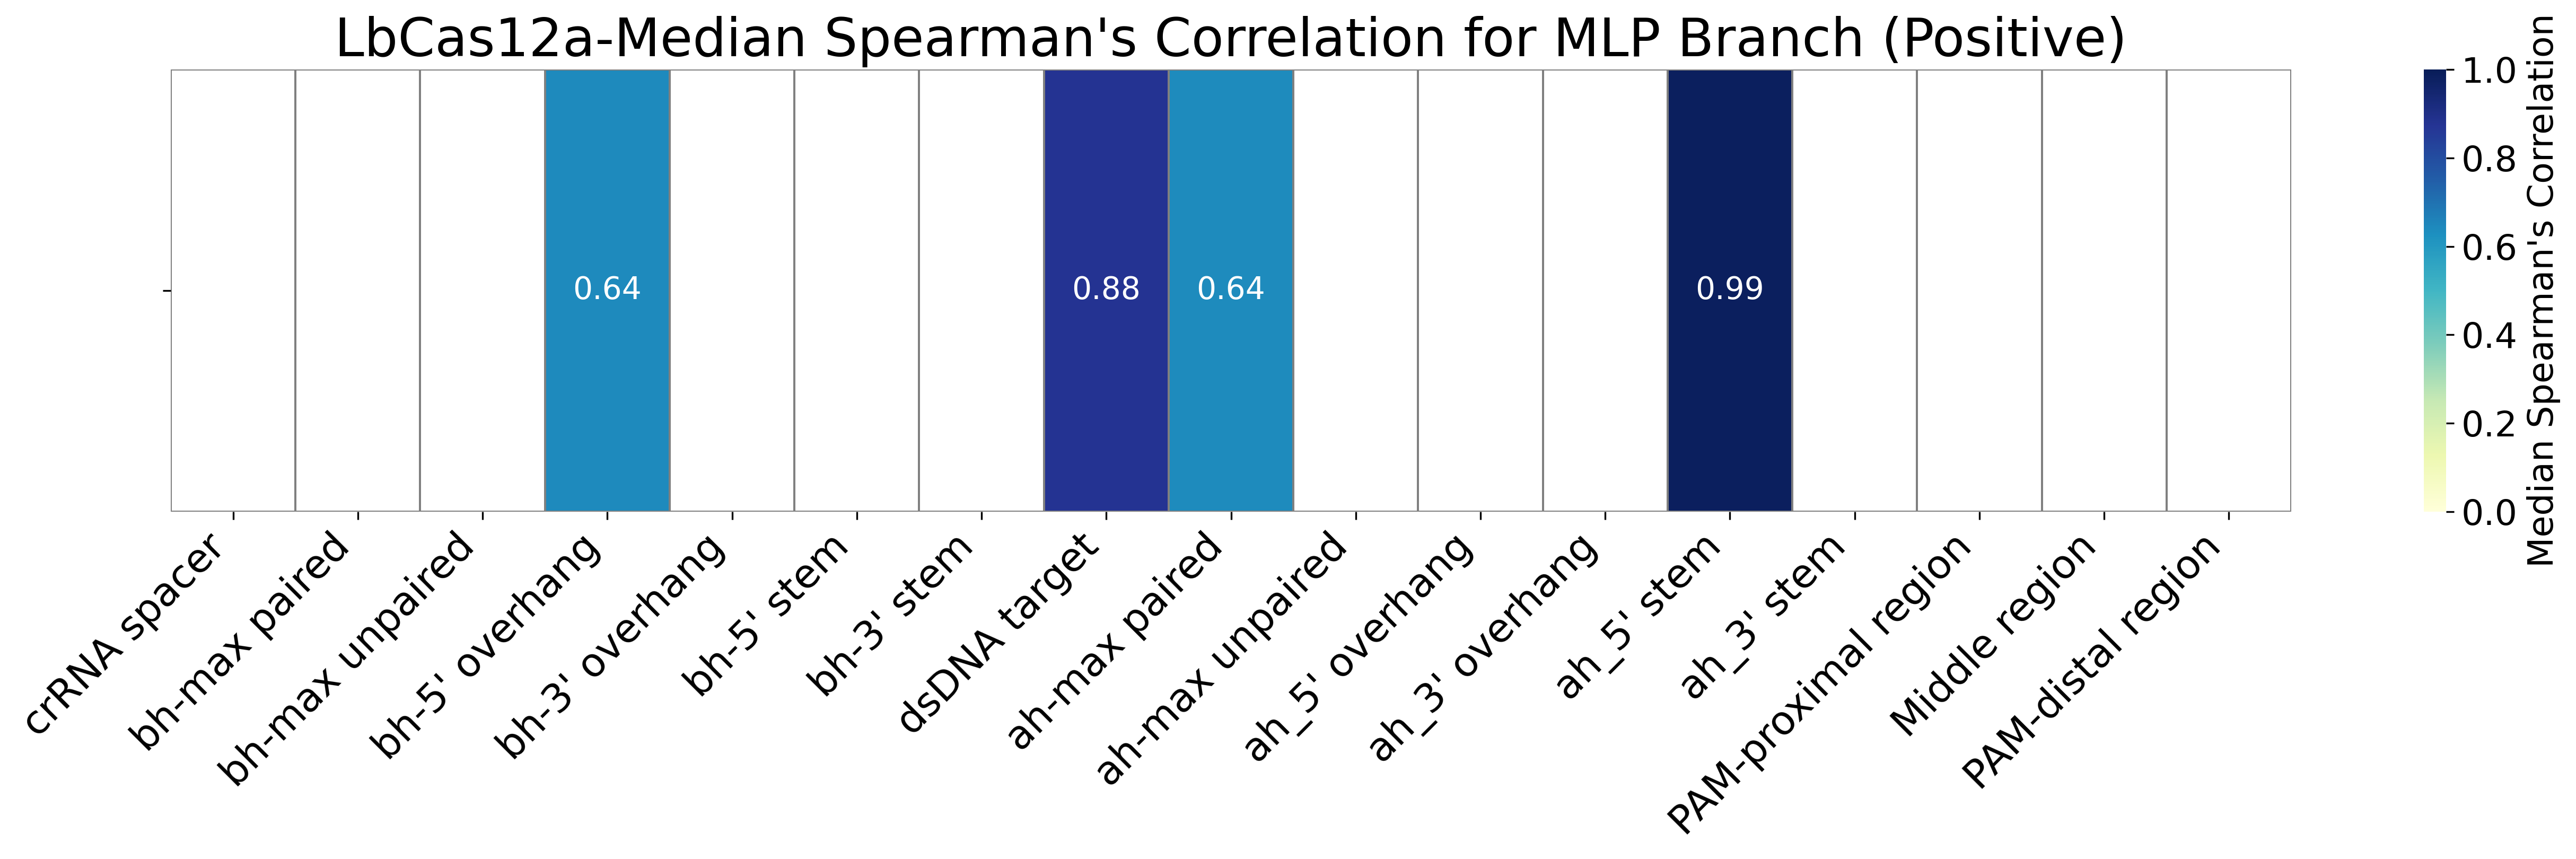

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- desired full feature order (17 columns) ----
feature_order = [
    "crRNA spacer",
    "bh_maximal consecutive paired bases",
    "bh_maximal consecutive unpaired bases",
    "bh_5' overhang",
    "bh_3' overhang",
    "bh_5' stem",
    "bh_3' stem",
    "dsDNA target",
    "ah_maximal consecutive paired bases",
    "ah_maximal consecutive unpaired bases",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "central region",
    "PAM-distal region"
]

csv_path = "features_with_positive_IQR_Specificity_model_mlp.csv"
value_col = "Median Spearman Correlation"   # change if your column name differs
feature_col = "Feature"                     # change if your feature-name column differs

# ---- load ----
df = pd.read_csv(csv_path)

# Optional: if duplicates exist, average them
df = df.groupby(feature_col, as_index=False)[value_col].mean()

# ---- build a 1x17 table: row label "MLP", columns are the 17 features ----
# Map available features into a Series indexed by Feature name
s = df.set_index(feature_col)[value_col]

# Reindex to force all 17 features to exist; missing -> NaN
s = s.reindex(feature_order)

heatmap_data = pd.DataFrame([s.values], index=[""], columns=feature_order)

# ---- plot (NaN will be blank if masked) ----
mask = heatmap_data.isna()

fig, ax = plt.subplots(figsize=(18, 5.5), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0, vmax=1,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Median Spearman's Correlation"},
    annot_kws={"fontsize": 14},
    ax=ax
)

ax.set_ylabel("")  # 1-row heatmap; optional
ax.set_xlabel("")
ax.set_title("LbCas12a-Median Spearman's Correlation for MLP Branch (Positive)", fontsize=24)

# Rotate x tick labels + align to the right (NOTE: use set_xticklabels for alignment)
short_labels = [
    "crRNA spacer",
    "bh-max paired",
    "bh-max unpaired",
    "bh-5' overhang",
    "bh-3' overhang",
    "bh-5' stem",
    "bh-3' stem",
    "dsDNA target",
    "ah-max paired",
    "ah-max unpaired",
    "ah_5' overhang",
    "ah_3' overhang",
    "ah_5' stem",
    "ah_3' stem",
    "PAM-proximal region",
    "Middle region",
    "PAM-distal region"
]

ax.set_xticklabels(short_labels, rotation=45, ha="right", fontsize=18)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=12)

# Colorbar font sizes
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=16)
cbar.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()


In [5]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Specificity_model_cnn1.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Specificity_model_cnn1.csv", index=False)


    Feature     Q1     Q3  Median Spearman Correlation
0   Pos22_A  0.766  0.766                        0.766
1   Pos23_A  0.763  0.763                        0.763
2   Pos23_C  0.564  0.651                        0.616
3   Pos24_A  0.598  0.735                        0.690
4   Pos25_A  0.669  0.744                        0.729
5   Pos25_T  0.340  0.737                        0.663
6   Pos26_A  0.406  0.719                        0.685
7   Pos26_C  0.639  0.734                        0.725
8   Pos26_T  0.549  0.776                        0.698
9   Pos27_A  0.489  0.690                        0.626
10  Pos27_C  0.605  0.715                        0.693
11  Pos27_T  0.773  0.783                        0.782
12  Pos28_A  0.760  0.769                        0.768
13  Pos28_C  0.398  0.700                        0.595
14  Pos28_T  0.642  0.776                        0.705
15  Pos29_A  0.463  0.739                        0.702
16  Pos29_C  0.721  0.739                        0.731
17  Pos29_

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_34193/166854562.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


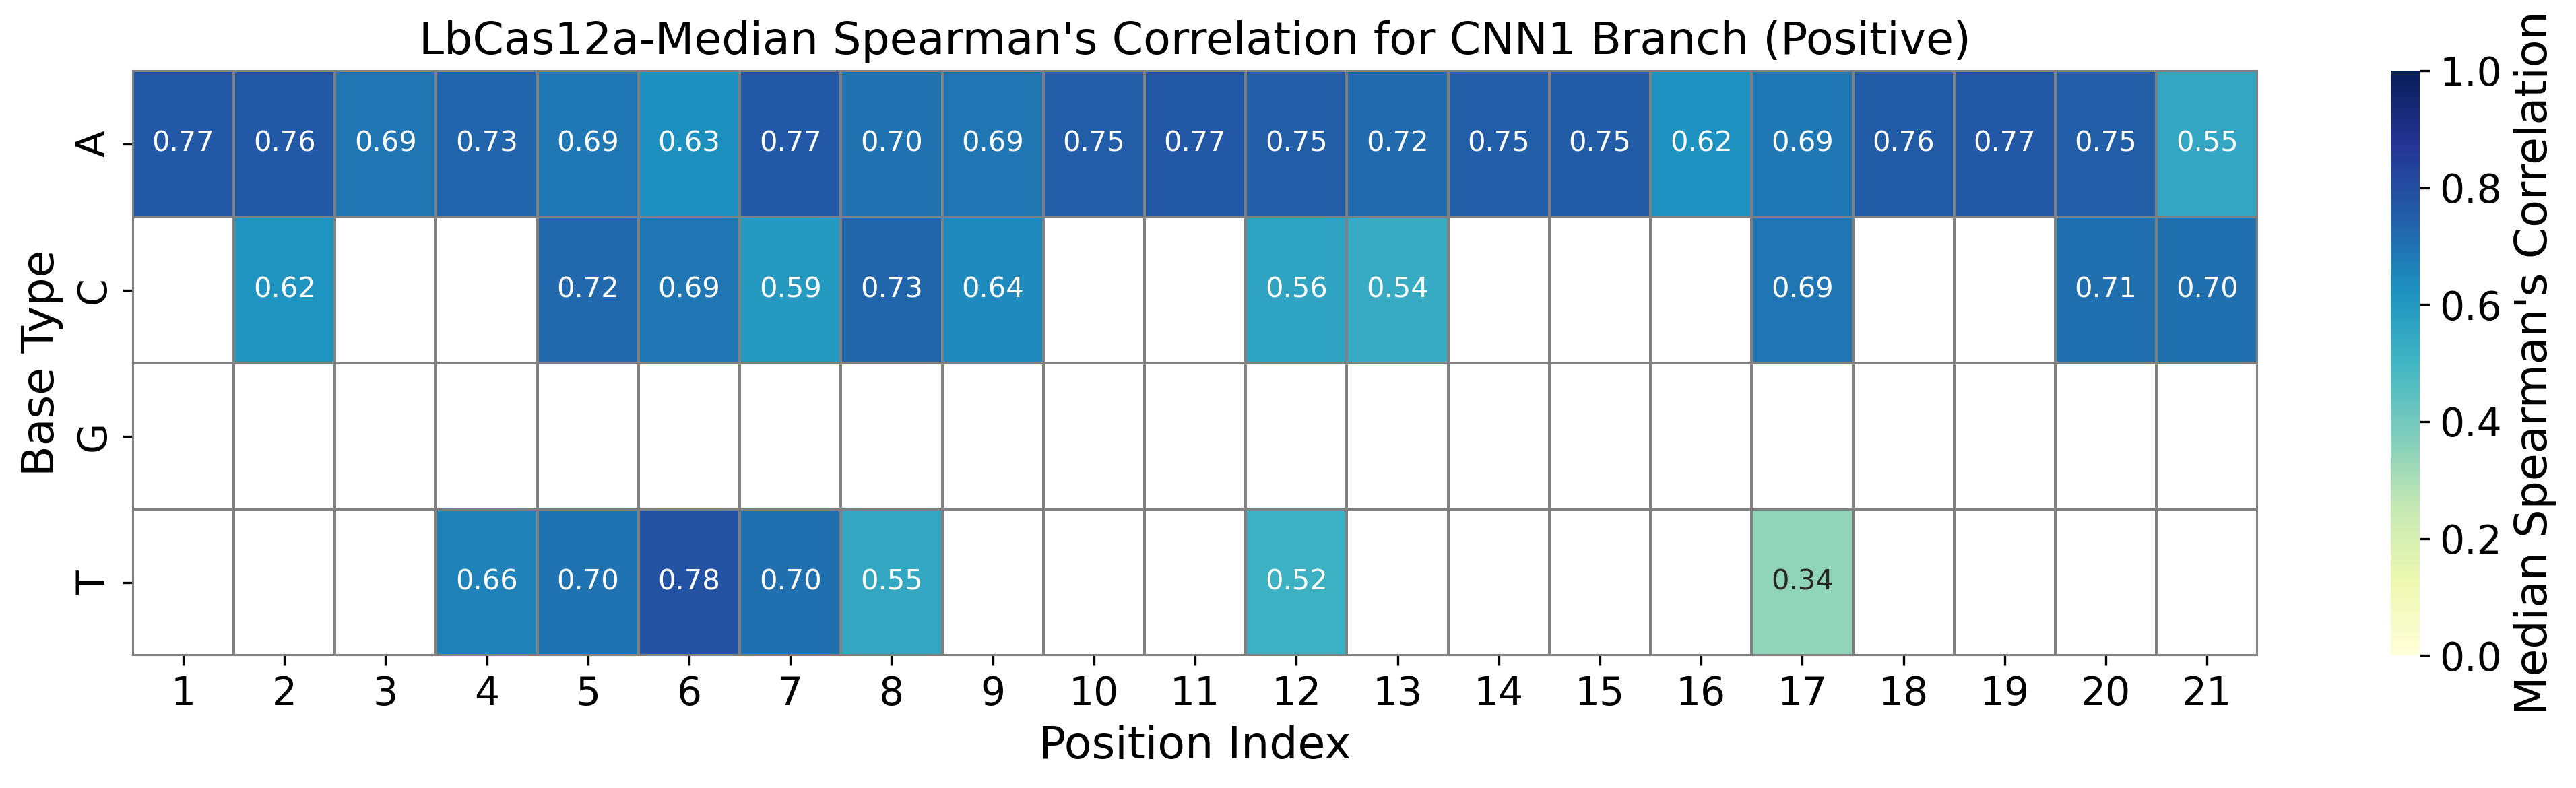

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load processed feature list
iqr_df = pd.read_csv("features_with_positive_IQR_Specificity_model_cnn1.csv")
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(\w)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# Pivot to heatmap format
heatmap_data = iqr_df.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Ensure all four bases are always shown in the desired order
base_order = ["A", "C", "G", "T"]
heatmap_data = heatmap_data.reindex(index=base_order)

# Ensure all expected position indices are shown
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

mask = heatmap_data.isna()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=mask,
    ax=ax
)

# Force x-axis labels to start from 1
n_pos = heatmap_data.shape[1]
ax.set_xticks(np.arange(n_pos) + 0.5)
ax.set_xticklabels(range(1, n_pos + 1), fontsize=14)


# === Fix for missing bottom and right borders ===
# Turn on all spines (border lines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')


# Set custom font sizes
ax.set_xlabel("Position Index", fontsize=16)
ax.set_ylabel("Base Type", fontsize=16)
ax.set_title("LbCas12a-Median Spearman's Correlation for CNN1 Branch (Positive)", fontsize=16)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# === Adjust colorbar font sizes ===
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Colorbar tick labels
cbar.set_label("Median Spearman's Correlation", fontsize=16)  # Colorbar title

plt.tight_layout()
plt.show()


In [11]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("spearman_duplicates_grouped_norepeat_Specificity_model_cnn2.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("features_with_positive_IQR_Specificity_model_cnn2.csv", index=False)


                 Feature     Q1     Q3  Median Spearman Correlation
0    Pos1_Paired-Opening  0.370  0.370                        0.370
1    Pos3_Paired-Opening  0.484  0.501                        0.501
2    Pos6_Paired-Opening  0.484  0.661                        0.600
3          Pos9_Unpaired  0.548  0.624                        0.597
4         Pos10_Unpaired  0.440  0.508                        0.482
5   Pos11_Paired-Opening  0.362  0.536                        0.413
6         Pos13_Unpaired  0.394  0.558                        0.528
7         Pos14_Unpaired  0.521  0.655                        0.594
8         Pos15_Unpaired  0.393  0.680                        0.661
9         Pos16_Unpaired  0.160  0.376                        0.350
10        Pos17_Unpaired  0.135  0.458                        0.369
11  Pos17_Paired-Opening  0.014  0.210                        0.094
12  Pos18_Paired-Opening  0.502  0.599                        0.550
13  Pos19_Paired-Opening  0.559  0.603          

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_34193/3154999669.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


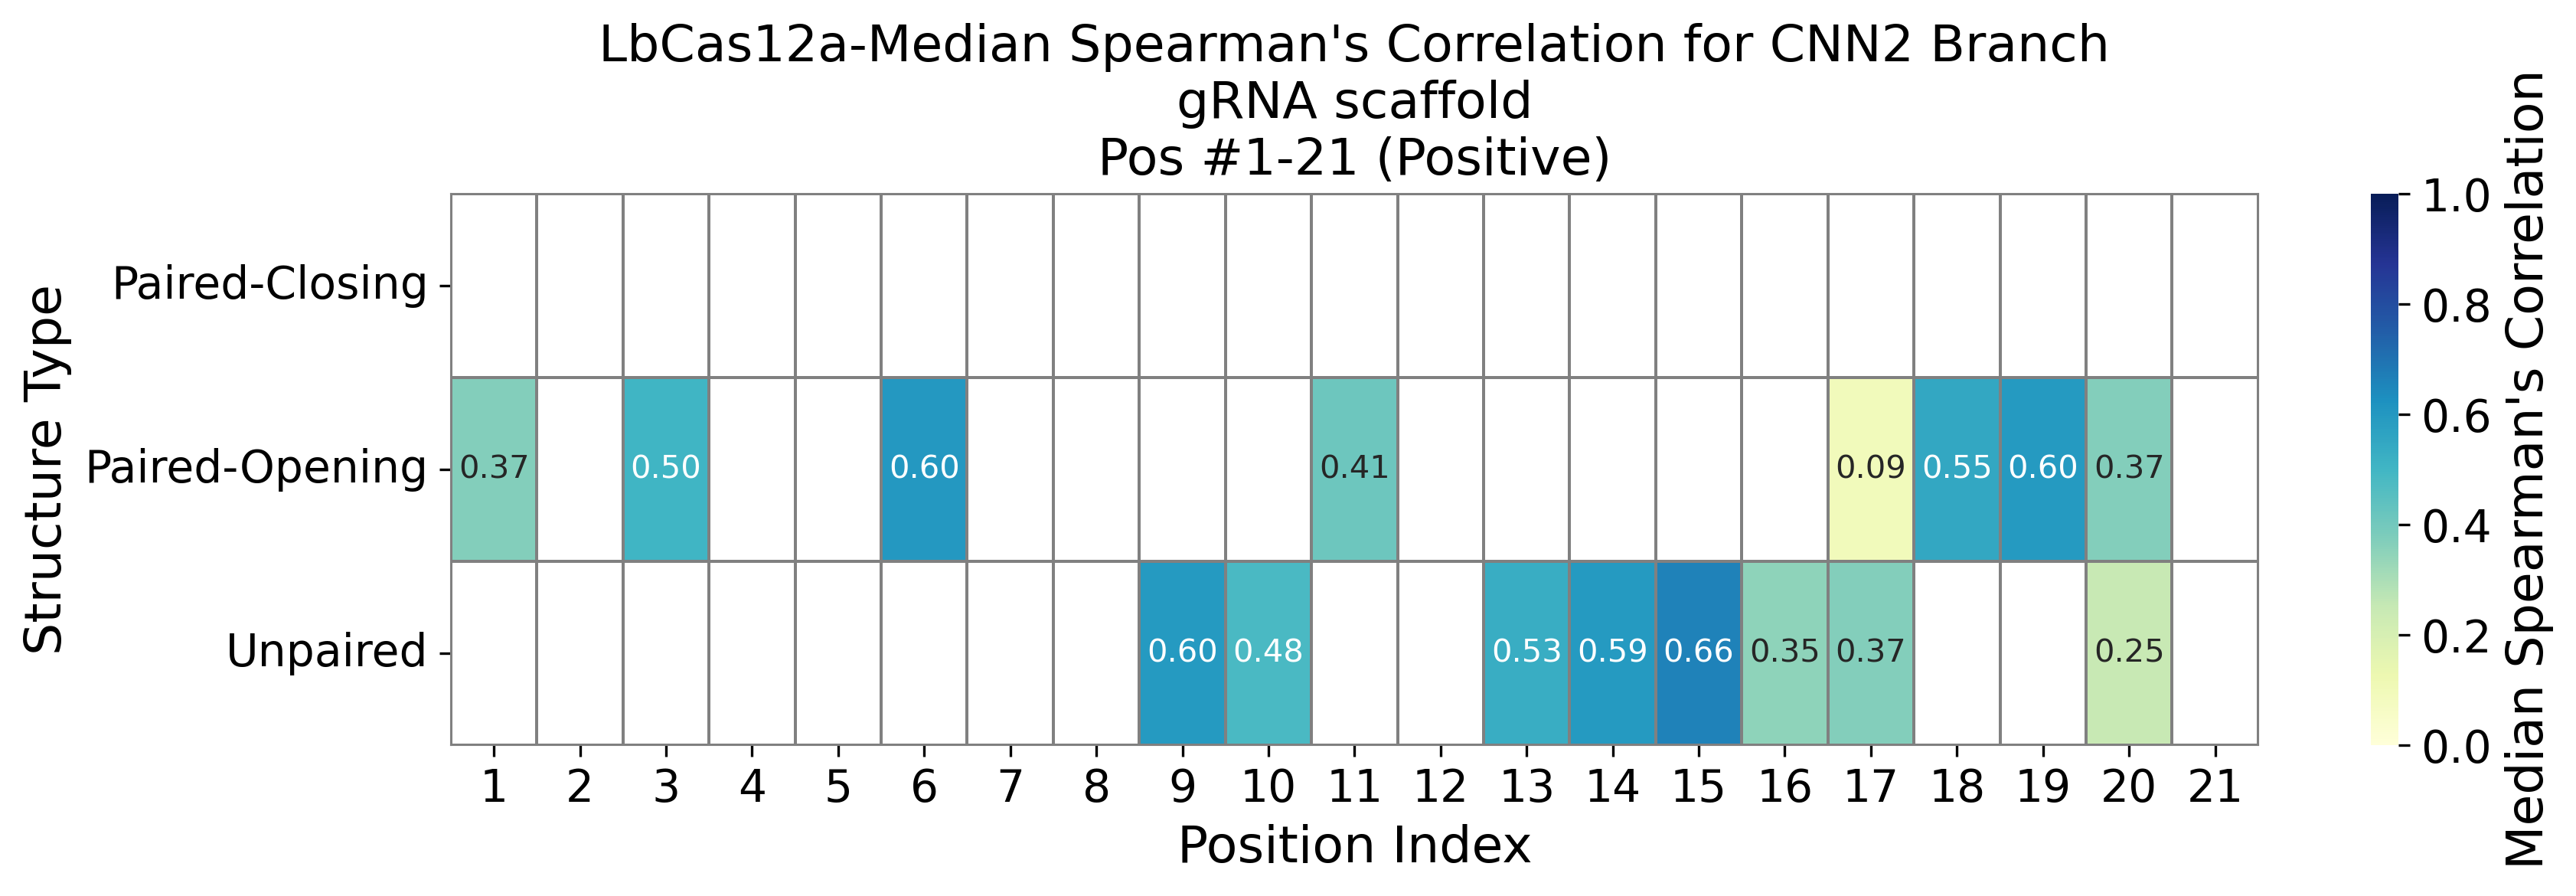

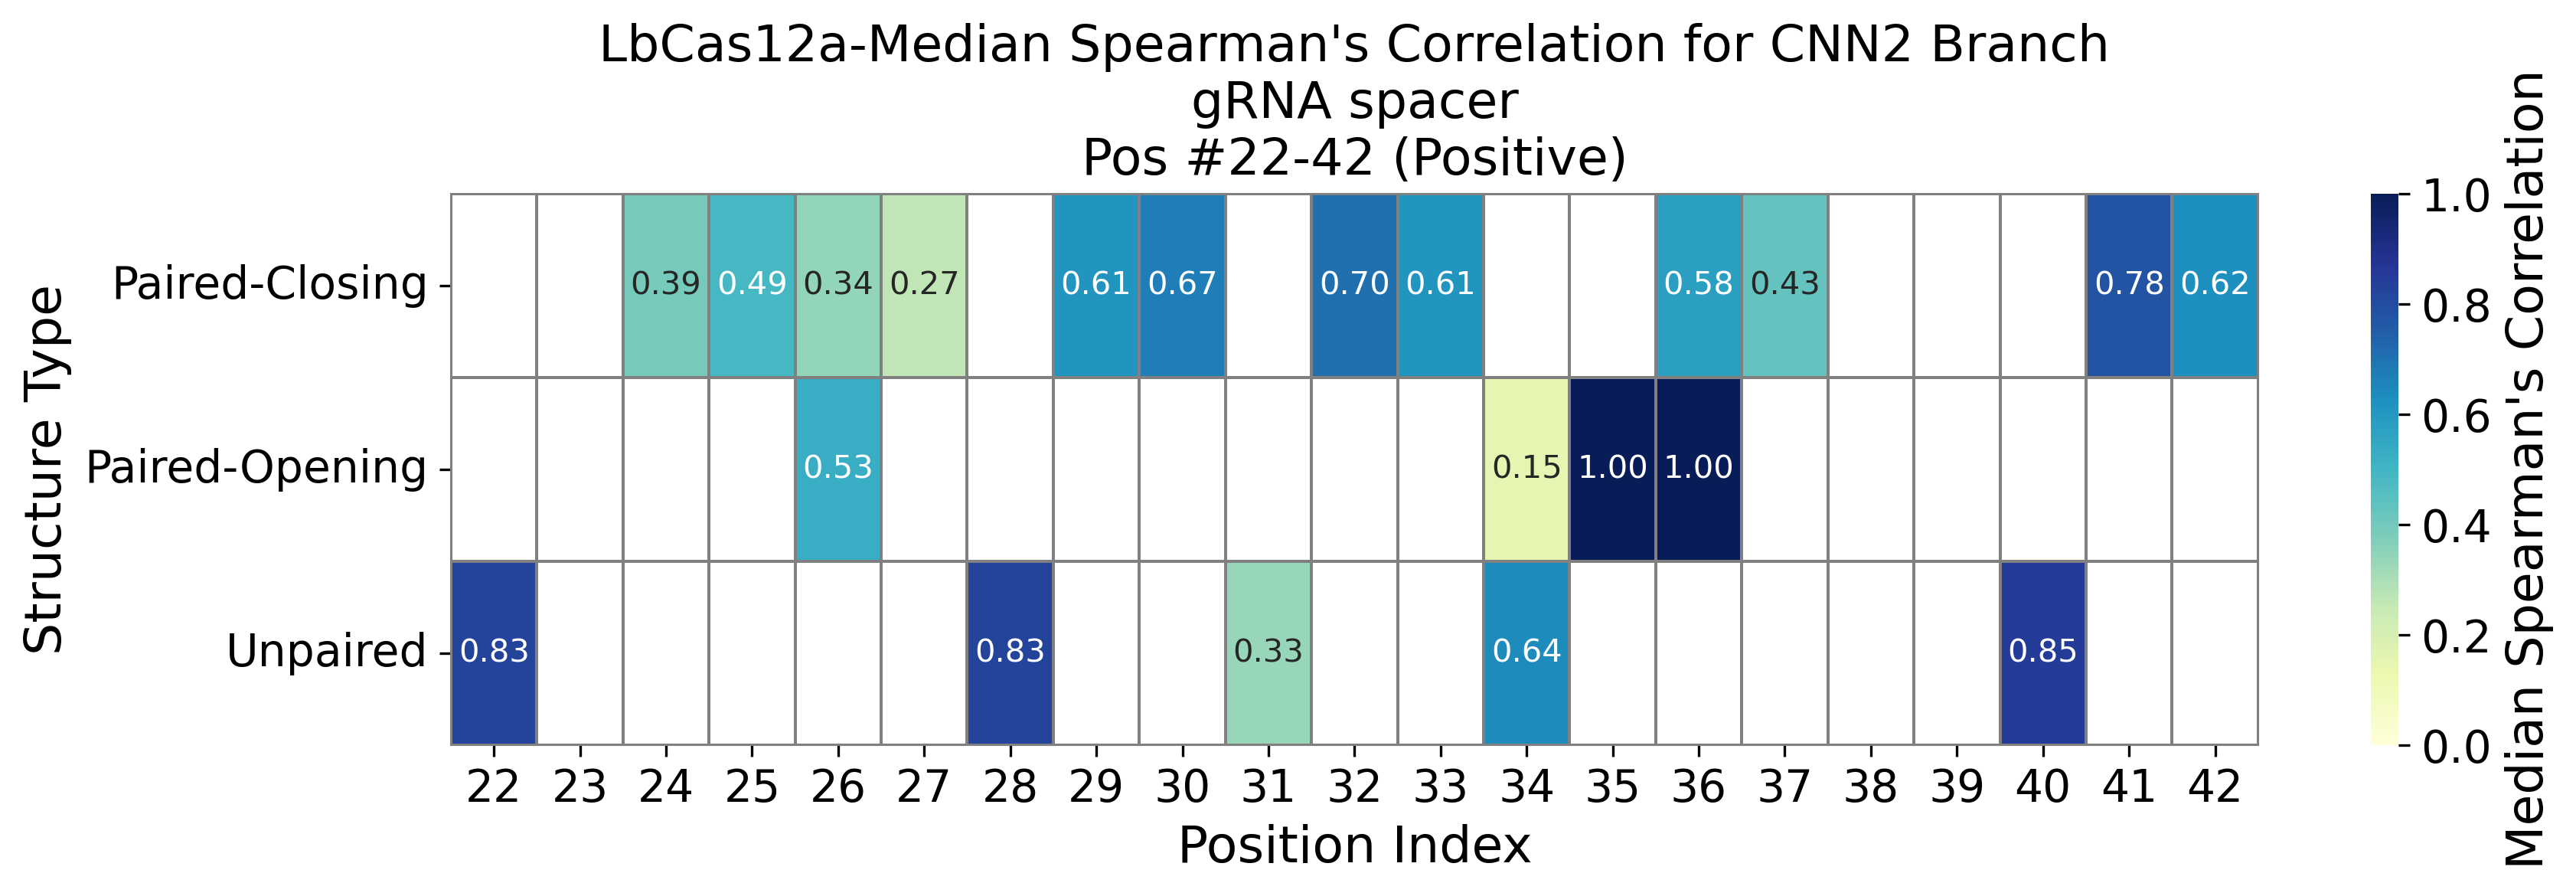

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# === Load processed feature list ===
iqr_df = pd.read_csv("features_with_positive_IQR_Specificity_model_cnn2.csv")

# === Extract Pos and Base Type (here Base = sub-feature like Paired, Opening, etc.) ===
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(.+)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# === Handle duplicate (Base, Pos) entries by averaging ===
iqr_df_grouped = iqr_df.groupby(['Base', 'Pos'])["Median Spearman Correlation"].mean().reset_index()

# === Pivot to heatmap format ===
heatmap_data = iqr_df_grouped.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Optional: Set fixed row order
row_order = sorted(heatmap_data.index.unique())
heatmap_data = heatmap_data.reindex(row_order)

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

# Create mask for missing values
mask = heatmap_data.isna()

# === Create two heatmap panels ===

# Heatmap for positions 1–21
fig1, ax1 = plt.subplots(figsize=(12, 4), dpi=300)
hm1 = sns.heatmap(
    heatmap_data.loc[:, 1:21],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 1:21].isna(),
    ax=ax1
)

for spine in ax1.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax1.set_xlabel("Position Index", fontsize=16)
ax1.set_ylabel("Structure Type", fontsize=16)
ax1.set_title(
    "LbCas12a-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA scaffold\n'
    "Pos #1-21 (Positive)",
    fontsize=16
)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar1 = hm1.collections[0].colorbar
cbar1.ax.tick_params(labelsize=14)
cbar1.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

# Heatmap for positions 22–42
fig2, ax2 = plt.subplots(figsize=(12, 4), dpi=300)
hm2 = sns.heatmap(
    heatmap_data.loc[:, 22:42],
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman's Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=heatmap_data.loc[:, 22:42].isna(),
    ax=ax2
)

for spine in ax2.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')

ax2.set_xlabel("Position Index", fontsize=16)
ax2.set_ylabel("Structure Type", fontsize=16)
ax2.set_title(
    "LbCas12a-Median Spearman's Correlation for CNN2 Branch\n"
    'gRNA spacer\n'
    "Pos #22-42 (Positive)",
    fontsize=16
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14, labelrotation=0)

cbar2 = hm2.collections[0].colorbar
cbar2.ax.tick_params(labelsize=14)
cbar2.set_label("Median Spearman's Correlation", fontsize=16)

plt.tight_layout()
plt.show()

